In [2]:
import numpy as np
from scipy.io import loadmat

def infer_delay_grid(cir_mat_path, rel_info_path, cir_key="CIR"):
    cir = loadmat(cir_mat_path)[cir_key]
    cir = np.squeeze(cir)  # (D, N) 형태로 만들기

    rel = loadmat(rel_info_path)
    rxh = rel["rx_header"][0,0]

    chiprate = int(rxh["chiprate"][0,0].item())      # Hz
    oversample = int(rxh["oversample"][0,0].item())  # 보통 raw/WS에 영향
    pn_period = int(rxh["pn_period"][0,0].item())    # 보통 4095

    D = cir.shape[0]

    # "D가 pn_period의 몇 배인가"로 실제 샘플링을 추정
    # (너 파일은 D=4095, pn_period=4095 -> factor=1)
    factor = D / pn_period

    # 보수적으로: factor가 정수에 가깝다면 그걸 사용
    if abs(factor - round(factor)) < 1e-6:
        factor = int(round(factor))
    else:
        # 애매하면 우선 1로 두고, 이후 검증(피크 위치 등)으로 보정
        factor = 1

    dt = 1.0 / (chiprate * factor)  # seconds per tap
    delay_s = np.arange(D) * dt
    delay_ns = delay_s * 1e9
    return delay_ns, dt, {"chiprate": chiprate, "pn_period": pn_period, "oversample": oversample, "D": D, "factor": factor}

delay_ns, dt, meta = infer_delay_grid("/home/mh/kmh/sionna-rt/mh/workspace/data_analyze/CIR.mat", "/home/mh/kmh/sionna-rt/mh/workspace/data_analyze/Rel_info.mat")
print(meta)
print("dt (ns) =", dt*1e9)

{'chiprate': 500000000, 'pn_period': 4095, 'oversample': 4, 'D': 4095, 'factor': 1}
dt (ns) = 2.0


In [3]:
import numpy as np
from scipy.io import loadmat

# 1) 로드
mat = loadmat("CIR.mat")
cir = np.squeeze(mat["CIR"])   # (4095, 281)

# 2) magnitude
cir_mag = np.abs(cir)

# 3) 정규화 (매우 중요)
cir_mag = cir_mag / np.max(cir_mag)

# 4) shape 바꾸기 → (time, delay)
cir_mag = cir_mag.T  # (281, 4095)

In [5]:
def make_dataset(data, input_len=8):
    X, Y = [], []
    for t in range(input_len, len(data)):
        X.append(data[t-input_len:t])
        Y.append(data[t])
    return np.array(X), np.array(Y)

X, Y = make_dataset(cir_mag, input_len=8)

print(X.shape)  # (samples, 8, 4095)
print(Y.shape)  # (samples, 4095)

(273, 8, 4095)
(273, 4095)


2026-03-03 16:15:22.919053: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 16:15:22.931633: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772522122.944899  235411 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772522122.949340  235411 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772522122.960639  235411 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

X: (273, 8, 4095)
Y: (273, 4095)
train/val/test: (191, 8, 4095) (41, 8, 4095) (41, 8, 4095)
Baseline Persist NMSE: 1.186677e+00  (0.74 dB)
Baseline Mean    NMSE: 9.127530e-01  (-0.40 dB)


I0000 00:00:1772522124.990732  235411 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 727 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:19:00.0, compute capability: 8.6


Model: "CNNPredictorTF"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ x_in (InputLayer)               │ (None, 8, 4095)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transpose_layer                 │ (None, 4095, 8)        │             0 │
│ (TransposeLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 4095, 32)       │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4095, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 4095, 1)        │           321 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ y_hat (Reshape)                 │ (None, 4095)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

Epoch 1/30


I0000 00:00:1772522126.396196  238364 service.cc:152] XLA service 0x72e054003c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772522126.396216  238364 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-03-03 16:15:26.424364: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1772522126.531862  238364 cuda_dnn.cc:529] Loaded cuDNN version 90300


 8/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.6197e-04 - nmse_tf: 0.6901

I0000 00:00:1772522128.048618  238364 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - loss: 1.2681e-04 - nmse_tf: 0.5256 - val_loss: 7.1972e-05 - val_nmse_tf: 0.2966 - learning_rate: 0.0010
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.2865e-05 - nmse_tf: 0.2193 - val_loss: 3.8593e-05 - val_nmse_tf: 0.1592 - learning_rate: 0.0010
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.3875e-05 - nmse_tf: 0.1404 - val_loss: 3.0991e-05 - val_nmse_tf: 0.1282 - learning_rate: 0.0010
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.4857e-05 - nmse_tf: 0.1031 - val_loss: 2.5952e-05 - val_nmse_tf: 0.1076 - learning_rate: 0.0010
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1258e-05 - nmse_tf: 0.0883 - val_loss: 2.5504e-05 - val_nmse_tf: 0.1067 - learning_rate: 0.0010
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.9106e-05 - nmse_tf: 0.0794 - val_loss: 2.5611e-05 - val_nmse_tf: 0.1074 - learning_rate: 0.0010
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.8111e-05 - nm

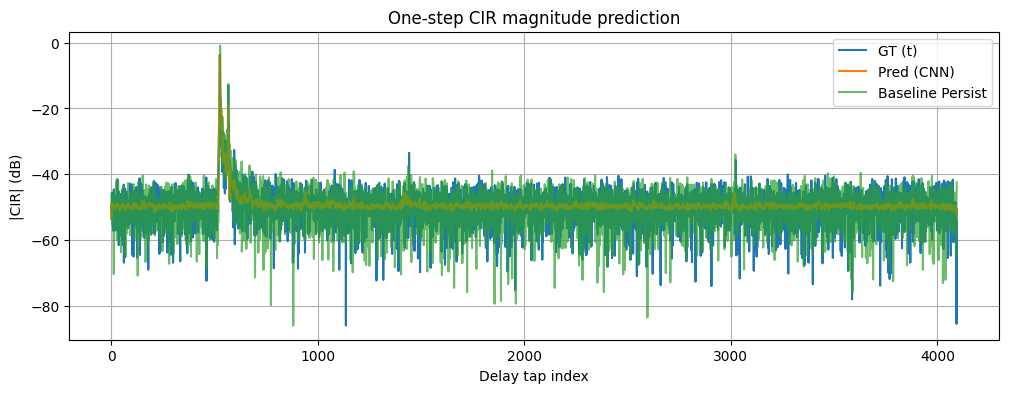

In [7]:
# ======================================================================
# CIR 미래 예측 (TensorFlow / Keras) - 1D CNN
# 입력:  과거 8개 스냅샷 (time=8) 의 |CIR|  -> shape (8, 4095)
# 출력:  다음 1개 스냅샷 (4095)
#
# X shape: (273, 8, 4095)
# Y shape: (273, 4095)
# ======================================================================

import numpy as np
import tensorflow as tf
from scipy.io import loadmat
import matplotlib.pyplot as plt

# -------------------------
# 0) Config
# -------------------------
CIR_MAT_PATH = "CIR.mat"      # 필요하면 경로 수정
REL_INFO_PATH = "Rel_info.mat"  # 지금은 사용 안해도 됨 (dt=2ns 확인용)
CIR_KEY = "CIR"

INPUT_LEN = 8
TARGET_LEN = 4095

BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-3
SEED = 123

np.random.seed(SEED)
tf.random.set_seed(SEED)

# -------------------------
# 1) Load & preprocess
# -------------------------
mat = loadmat(CIR_MAT_PATH)
cir = np.squeeze(mat[CIR_KEY])  # 보통 (4095, 281)

# (delay, time)로 맞추기
if cir.shape[0] != TARGET_LEN and cir.shape[1] == TARGET_LEN:
    cir = np.swapaxes(cir, 0, 1)
if cir.shape[0] != TARGET_LEN:
    raise ValueError(f"CIR delay축이 {TARGET_LEN}이 아님: {cir.shape}")

# magnitude로 예측 (첫 PoC에 가장 안정적)
cir_mag = np.abs(cir).astype(np.float32)  # (4095, N)

# 정규화 (전체 peak 기준)
cir_mag = cir_mag / (np.max(cir_mag) + 1e-12)

# (time, delay)
cir_mag = cir_mag.T  # (N, 4095)

def make_dataset(arr_td, input_len=8):
    X, Y = [], []
    for t in range(input_len, arr_td.shape[0]):
        X.append(arr_td[t-input_len:t])  # (input_len, delay)
        Y.append(arr_td[t])              # (delay,)
    return np.asarray(X, np.float32), np.asarray(Y, np.float32)

X, Y = make_dataset(cir_mag, INPUT_LEN)

print("X:", X.shape)  # (273, 8, 4095)
print("Y:", Y.shape)  # (273, 4095)

# -------------------------
# 2) Time-ordered split (중요: 누수 방지)
# -------------------------
n = X.shape[0]
n_train = int(n * 0.70)
n_val   = int(n * 0.85)

X_train, Y_train = X[:n_train], Y[:n_train]
X_val,   Y_val   = X[n_train:n_val], Y[n_train:n_val]
X_test,  Y_test  = X[n_val:], Y[n_val:]

print("train/val/test:", X_train.shape, X_val.shape, X_test.shape)

# -------------------------
# 3) Baselines (발표용 필수)
# -------------------------
def nmse_np(y_hat, y):
    return np.mean((y_hat - y)**2) / (np.mean(y**2) + 1e-12)

Yhat_persist = X_test[:, -1, :]             # 마지막 입력 복사
Yhat_mean    = np.mean(X_test, axis=1)      # 시간 평균

nmse_p = nmse_np(Yhat_persist, Y_test)
nmse_m = nmse_np(Yhat_mean, Y_test)

print(f"Baseline Persist NMSE: {nmse_p:.6e}  ({10*np.log10(nmse_p+1e-12):.2f} dB)")
print(f"Baseline Mean    NMSE: {nmse_m:.6e}  ({10*np.log10(nmse_m+1e-12):.2f} dB)")

# -------------------------
# 4) tf.data pipeline
# -------------------------
train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, Y_val)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, Y_test)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

# -------------------------
# 5) Model (PyTorch CNNPredictor -> TF/Keras 동일 구조)
#   Conv1D는 마지막 축을 길이로 보고, 채널은 feature로 봄
#   현재 X: (batch, time=8, delay=4095)
#   여기서 "채널=8, 길이=4095"로 쓰려면 transpose 필요
#   Keras Conv1D 입력은 (batch, steps, channels) 기본이라
#   steps=4095, channels=8로 바꿔서 conv 수행 후
#   다시 (4095,)로 출력
# -------------------------
class TransposeLayer(tf.keras.layers.Layer):
    def call(self, x):
        # (B, 8, 4095) -> (B, 4095, 8)
        return tf.transpose(x, perm=[0, 2, 1])

def build_model():
    inp = tf.keras.Input(shape=(INPUT_LEN, TARGET_LEN), name="x_in")  # (8, 4095)
    x = TransposeLayer()(inp)                                         # (4095, 8)

    x = tf.keras.layers.Conv1D(32, kernel_size=5, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv1D(1,  kernel_size=5, padding="same")(x)  # (4095, 1)

    x = tf.keras.layers.Reshape((TARGET_LEN,), name="y_hat")(x)       # (4095,)
    return tf.keras.Model(inputs=inp, outputs=x, name="CNNPredictorTF")

model = build_model()
model.summary()

# -------------------------
# 6) Loss / Metric (NMSE)
# -------------------------
def nmse_tf(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_pred - y_true))
    denom = tf.reduce_mean(tf.square(y_true)) + 1e-12
    return mse / denom

# 훈련은 MSE로 하고, 모니터링은 NMSE로 같이 보기 추천
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss="mse",
    metrics=[nmse_tf],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_nmse_tf", mode="min", patience=6, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_nmse_tf", mode="min", factor=0.5, patience=3, min_lr=1e-5
    )
]

# -------------------------
# 7) Train
# -------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# -------------------------
# 8) Evaluate
# -------------------------
test_metrics = model.evaluate(test_ds, verbose=0)
print(f"Test loss(MSE): {test_metrics[0]:.6e}")
print(f"Test NMSE     : {test_metrics[1]:.6e} ({10*np.log10(test_metrics[1]+1e-12):.2f} dB)")

# Baseline 대비 개선량
nmse_model = float(test_metrics[1])
print(f"Δ(dB) vs Persist = {(10*np.log10(nmse_p+1e-12) - 10*np.log10(nmse_model+1e-12)):.2f} dB 개선")
print(f"Δ(dB) vs Mean    = {(10*np.log10(nmse_m+1e-12) - 10*np.log10(nmse_model+1e-12)):.2f} dB 개선")

# -------------------------
# 9) 시각화: 테스트에서 한 샘플 예측 vs 정답 (PDP처럼 보기)
# -------------------------
# 한 배치에서 하나 뽑아 예측
x0 = X_test[0:1]                  # (1, 8, 4095)
y_true0 = Y_test[0]               # (4095,)
y_pred0 = model.predict(x0, verbose=0)[0]  # (4095,)

# dB 스케일 (0 회피용 eps)
eps = 1e-12
y_true_db = 20*np.log10(np.maximum(y_true0, eps))
y_pred_db = 20*np.log10(np.maximum(y_pred0, eps))
y_last_db = 20*np.log10(np.maximum(X_test[0, -1, :], eps))  # persist 비교

plt.figure(figsize=(12,4))
plt.plot(y_true_db, label="GT (t)")
plt.plot(y_pred_db, label="Pred (CNN)")
plt.plot(y_last_db, label="Baseline Persist", alpha=0.7)
plt.xlabel("Delay tap index")
plt.ylabel("|CIR| (dB)")
plt.title("One-step CIR magnitude prediction")
plt.grid(True)
plt.legend()
plt.show()

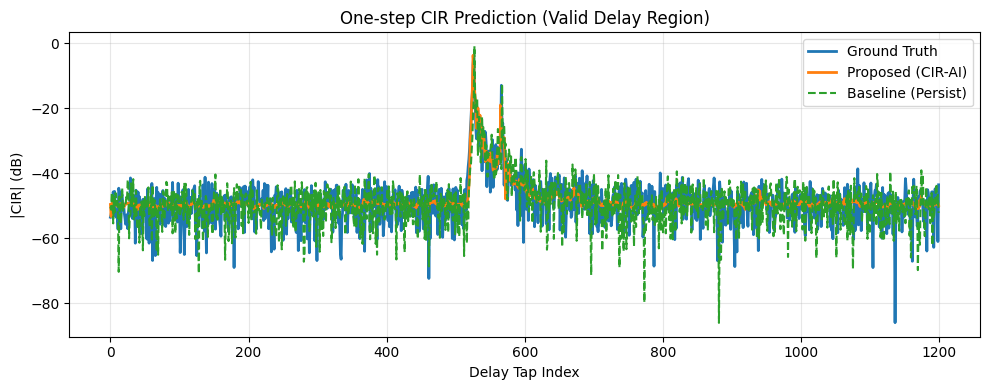

In [8]:
# ======================================
# 발표용 그래프 (유효 delay 구간 확대)
# ======================================

L = 1200   # 앞쪽 유효 구간만 보기
idx = 0    # 테스트 샘플 인덱스

eps = 1e-12

y_true = Y_test[idx, :L]
y_pred = model.predict(X_test[idx:idx+1], verbose=0)[0, :L]
y_persist = X_test[idx, -1, :L]

y_true_db = 20*np.log10(np.maximum(y_true, eps))
y_pred_db = 20*np.log10(np.maximum(y_pred, eps))
y_persist_db = 20*np.log10(np.maximum(y_persist, eps))

plt.figure(figsize=(10,4))
plt.plot(y_true_db, linewidth=2, label="Ground Truth")
plt.plot(y_pred_db, linewidth=2, label="Proposed (CIR-AI)")
plt.plot(y_persist_db, linestyle="--", label="Baseline (Persist)")

plt.xlabel("Delay Tap Index")
plt.ylabel("|CIR| (dB)")
plt.title("One-step CIR Prediction (Valid Delay Region)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

cir_mag (time, delay): (281, 4095)

[Horizon = 1]  (입력 8개 → 1-step 미래 1개)
Shapes: X_train (191, 8, 4095) Y_train (191, 4095) | X_val (41, 8, 4095) | X_test (41, 8, 4095)
Baseline Persist NMSE: 1.186677e+00 (0.74 dB)
Baseline Mean    NMSE: 9.127530e-01 (-0.40 dB)
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 2.1449e-04 - nmse_tf: 0.8858 - val_loss: 1.7901e-04 - val_nmse_tf: 0.7409 - learning_rate: 0.0010
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1275e-04 - nmse_tf: 0.4675 - val_loss: 6.2922e-05 - val_nmse_tf: 0.2610 - learning_rate: 0.0010
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.9437e-05 - nmse_tf: 0.2049 - val_loss: 4.2162e-05 - val_nmse_tf: 0.1756 - learning_rate: 0.0010
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.1941e-05 - nmse_tf: 0.1325 - val_loss: 3.2569e-05 - val_nmse_tf: 0.1365 - learning_rate: 0.0010
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.3630e-05 - nmse_tf: 0.0981 - val_loss: 2.8763e-05 -

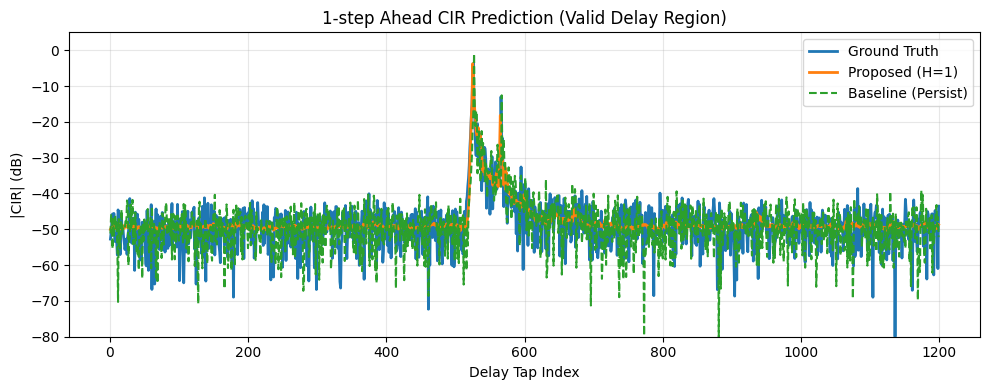

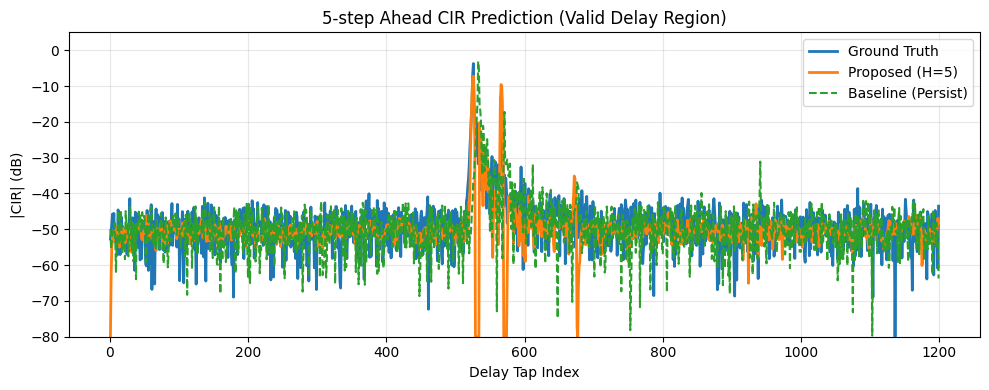

In [12]:
# ======================================================================
# CIR 미래 예측 (TensorFlow / Keras) - 1D CNN
#  - 1-step + 5-step 모두 학습/평가/그래프 출력
#  - magnitude(|CIR|) 예측이므로 마지막 레이어에 ReLU 적용 (음수 방지)
#
# 입력 데이터: CIR.mat (변수명 "CIR")  -> (delay=4095, time=281) 또는 전치 형태
# ======================================================================

import numpy as np
import tensorflow as tf
from scipy.io import loadmat
import matplotlib.pyplot as plt

# -------------------------
# 0) Config
# -------------------------
CIR_MAT_PATH = "CIR.mat"      # 필요하면 경로 수정
CIR_KEY = "CIR"

TARGET_LEN = 4095
INPUT_LEN = 8

HORIZONS = (1, 5)             # 1-step, 5-step
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-3
SEED = 123

np.random.seed(SEED)
tf.random.set_seed(SEED)

# -------------------------
# 1) Load & preprocess
# -------------------------
mat = loadmat(CIR_MAT_PATH)
cir = np.squeeze(mat[CIR_KEY])  # 보통 (4095, 281)

# (delay, time)로 맞추기
if cir.shape[0] != TARGET_LEN and cir.shape[1] == TARGET_LEN:
    cir = np.swapaxes(cir, 0, 1)

if cir.shape[0] != TARGET_LEN:
    raise ValueError(f"CIR delay축이 {TARGET_LEN}이 아님: {cir.shape}")

# magnitude
cir_mag = np.abs(cir).astype(np.float32)  # (4095, T)

# 정규화 (전체 peak 기준)
cir_mag = cir_mag / (np.max(cir_mag) + 1e-12)

# (time, delay)
cir_mag = cir_mag.T  # (T, 4095)
print("cir_mag (time, delay):", cir_mag.shape)

# -------------------------
# 2) Dataset builders
# -------------------------
def make_dataset_horizon(arr_td, input_len=8, horizon=1):
    """
    arr_td: (T, D)
    X: (T-input_len-horizon+1, input_len, D)
    Y: (T-input_len-horizon+1, D)  -> t+horizon-1 타깃
    """
    X, Y = [], []
    T = arr_td.shape[0]
    for t in range(input_len, T - horizon + 1):
        X.append(arr_td[t-input_len:t])
        Y.append(arr_td[t + horizon - 1])
    return np.asarray(X, np.float32), np.asarray(Y, np.float32)

def time_split(X, Y, train_ratio=0.70, val_ratio=0.15):
    n = X.shape[0]
    n_train = int(n * train_ratio)
    n_val = int(n * (train_ratio + val_ratio))
    return (X[:n_train], Y[:n_train],
            X[n_train:n_val], Y[n_train:n_val],
            X[n_val:], Y[n_val:])

def nmse_np(y_hat, y):
    return np.mean((y_hat - y)**2) / (np.mean(y**2) + 1e-12)

def nmse_tf(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_pred - y_true))
    denom = tf.reduce_mean(tf.square(y_true)) + 1e-12
    return mse / denom

# -------------------------
# 3) Model (ReLU in last layer to avoid negative magnitude)
# -------------------------
class TransposeLayer(tf.keras.layers.Layer):
    def call(self, x):
        # (B, time=8, delay=4095) -> (B, delay=4095, channels=8)
        return tf.transpose(x, perm=[0, 2, 1])

def build_model(input_len=8, target_len=4095):
    inp = tf.keras.Input(shape=(input_len, target_len), name="x_in")  # (8, 4095)
    x = TransposeLayer()(inp)                                         # (4095, 8)

    x = tf.keras.layers.Conv1D(32, kernel_size=5, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)

    # ★ 마지막 레이어에 ReLU 추가 (magnitude >= 0 보장)
    x = tf.keras.layers.Conv1D(1, kernel_size=5, padding="same", activation="relu")(x)  # (4095, 1)

    out = tf.keras.layers.Reshape((target_len,), name="y_hat")(x)     # (4095,)
    return tf.keras.Model(inputs=inp, outputs=out, name="CNNPredictorTF_ReLU")

# -------------------------
# 4) Plot helper (발표용: floor 적용 + 0번 tap 제외 옵션)
# -------------------------
def to_db_floor(x, floor_db=-80.0):
    x = np.maximum(x, 10**(floor_db/20))
    return 20*np.log10(x)

def plot_example(model, X_test, Y_test, horizon, L=1200, idx=0, floor_db=-80.0, skip0=True):
    a = 1 if skip0 else 0
    b = min(L, Y_test.shape[1])

    y_true = Y_test[idx, a:b]
    y_pred = model.predict(X_test[idx:idx+1], verbose=0)[0, a:b]
    y_persist = X_test[idx, -1, a:b]

    y_true_db = to_db_floor(y_true, floor_db)
    y_pred_db = to_db_floor(y_pred, floor_db)
    y_persist_db = to_db_floor(y_persist, floor_db)

    xs = np.arange(a, b)
    plt.figure(figsize=(10,4))
    plt.plot(xs, y_true_db, linewidth=2, label="Ground Truth")
    plt.plot(xs, y_pred_db, linewidth=2, label=f"Proposed (H={horizon})")
    plt.plot(xs, y_persist_db, linestyle="--", label="Baseline (Persist)")
    plt.ylim(floor_db, 5)
    plt.xlabel("Delay Tap Index")
    plt.ylabel("|CIR| (dB)")
    plt.title(f"{horizon}-step Ahead CIR Prediction (Valid Delay Region)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------------
# 5) Train/Eval loop for (H=1, H=5)
# -------------------------
results = {}
models = {}
splits = {}

for H in HORIZONS:
    print("\n" + "="*70)
    print(f"[Horizon = {H}]  (입력 {INPUT_LEN}개 → {H}-step 미래 1개)")
    print("="*70)

    # dataset
    X, Y = make_dataset_horizon(cir_mag, input_len=INPUT_LEN, horizon=H)
    X_train, Y_train, X_val, Y_val, X_test, Y_test = time_split(X, Y)

    print("Shapes:",
          "X_train", X_train.shape, "Y_train", Y_train.shape,
          "| X_val", X_val.shape, "| X_test", X_test.shape)

    # baselines
    Yhat_persist = X_test[:, -1, :]
    Yhat_mean = X_test.mean(axis=1)

    nmse_p = nmse_np(Yhat_persist, Y_test)
    nmse_m = nmse_np(Yhat_mean, Y_test)

    print(f"Baseline Persist NMSE: {nmse_p:.6e} ({10*np.log10(nmse_p+1e-12):.2f} dB)")
    print(f"Baseline Mean    NMSE: {nmse_m:.6e} ({10*np.log10(nmse_m+1e-12):.2f} dB)")

    # tf.data
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_ds   = tf.data.Dataset.from_tensor_slices((X_val, Y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    test_ds  = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # model
    model = build_model(INPUT_LEN, TARGET_LEN)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss="mse",
        metrics=[nmse_tf],
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_nmse_tf", mode="min", patience=6, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_nmse_tf", mode="min", factor=0.5, patience=3, min_lr=1e-5
        )
    ]

    model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=1)

    # eval
    test_loss, test_nmse = model.evaluate(test_ds, verbose=0)

    imp_vs_persist = 10*np.log10(nmse_p+1e-12) - 10*np.log10(test_nmse+1e-12)
    imp_vs_mean    = 10*np.log10(nmse_m+1e-12) - 10*np.log10(test_nmse+1e-12)

    print(f"Test NMSE: {test_nmse:.6e} ({10*np.log10(test_nmse+1e-12):.2f} dB)")
    print(f"Δ(dB) vs Persist: {imp_vs_persist:.2f} dB 개선")
    print(f"Δ(dB) vs Mean   : {imp_vs_mean:.2f} dB 개선")

    # sanity check: negative outputs should be gone
    y_pred0 = model.predict(X_test[0:1], verbose=0)[0]
    print("Sanity | min(y_pred0 linear) =", float(np.min(y_pred0)))

    # store
    results[H] = {
        "baseline_persist_db": float(10*np.log10(nmse_p+1e-12)),
        "baseline_mean_db": float(10*np.log10(nmse_m+1e-12)),
        "model_db": float(10*np.log10(test_nmse+1e-12)),
        "imp_vs_persist_db": float(imp_vs_persist),
        "imp_vs_mean_db": float(imp_vs_mean),
        "test_nmse": float(test_nmse),
        "baseline_persist_nmse": float(nmse_p),
        "baseline_mean_nmse": float(nmse_m),
    }
    models[H] = model
    splits[H] = (X_test, Y_test)

# -------------------------
# 6) 발표용 요약 출력
# -------------------------
print("\n" + "="*70)
print("발표용 요약 (NMSE dB: 낮을수록 좋음)")
print("="*70)
for H in HORIZONS:
    r = results[H]
    print(f"H={H} | Persist {r['baseline_persist_db']:.2f} dB | Mean {r['baseline_mean_db']:.2f} dB | "
          f"Model {r['model_db']:.2f} dB | +{r['imp_vs_persist_db']:.2f} dB(vs Persist)")

# -------------------------
# 7) 발표용 그래프 (H=1, H=5)
# -------------------------
for H in HORIZONS:
    X_test, Y_test = splits[H]
    plot_example(models[H], X_test, Y_test, horizon=H, L=1200, idx=0, floor_db=-80.0, skip0=True)

In [11]:
H = 5
idx = 0
L = 1200

model = models[H]
X_test, Y_test = samples[H]

y_pred = model.predict(X_test[idx:idx+1], verbose=0)[0, :L]
print("min y_pred (linear):", y_pred.min())
print("num < floor:", np.sum(y_pred < 10**(-100/20)))

min y_pred (linear): -0.0041429256
num < floor: 4


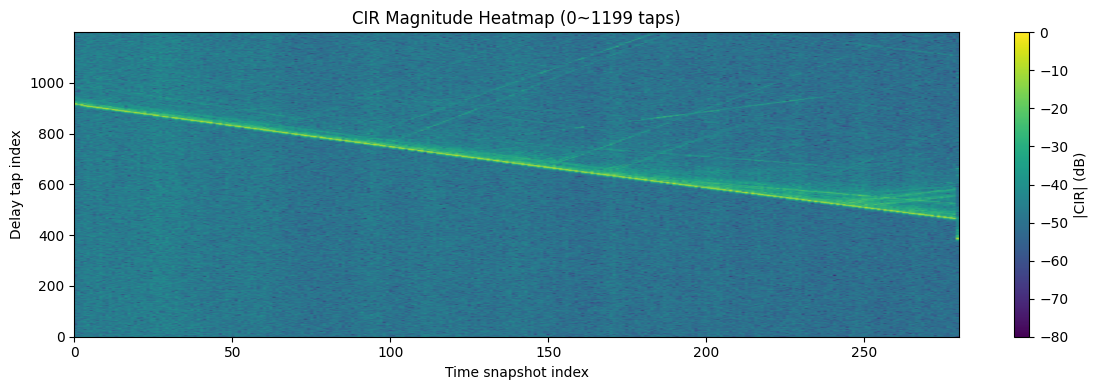

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# cir_mag: (T, D) = (281, 4095)
T, D = cir_mag.shape

L = 1200          # 앞쪽만 보고 싶으면 줄이기 (전체는 4095)
floor_db = -80    # 발표용 floor
eps_lin = 10**(floor_db/20)

Z = cir_mag[:, :L]
Z_db = 20*np.log10(np.maximum(Z, eps_lin))  # (T, L)

plt.figure(figsize=(12,4))
plt.imshow(Z_db.T, aspect='auto', origin='lower',
           extent=[0, T-1, 0, L-1])  # x=time, y=delay
plt.colorbar(label="|CIR| (dB)")
plt.xlabel("Time snapshot index")
plt.ylabel("Delay tap index")
plt.title(f"CIR Magnitude Heatmap (0~{L-1} taps)")
plt.tight_layout()
plt.show()

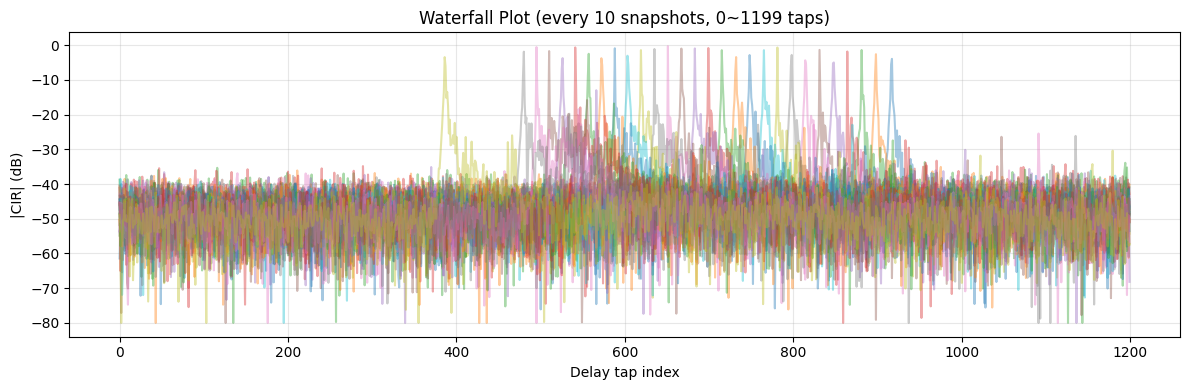

In [14]:
import numpy as np
import matplotlib.pyplot as plt

T, D = cir_mag.shape
L = 1200
step = 10        # 10개마다 한 번씩 그리기
floor_db = -80
eps_lin = 10**(floor_db/20)

plt.figure(figsize=(12,4))
for t in range(0, T, step):
    y_db = 20*np.log10(np.maximum(cir_mag[t, :L], eps_lin))
    plt.plot(y_db, alpha=0.4)

plt.xlabel("Delay tap index")
plt.ylabel("|CIR| (dB)")
plt.title(f"Waterfall Plot (every {step} snapshots, 0~{L-1} taps)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

out_dir = "cir_plots"
os.makedirs(out_dir, exist_ok=True)

T, D = cir_mag.shape
L = 1200
floor_db = -80
eps_lin = 10**(floor_db/20)

for t in range(T):
    y_db = 20*np.log10(np.maximum(cir_mag[t, :L], eps_lin))

    plt.figure(figsize=(10,3))
    plt.plot(y_db, linewidth=1.2)
    plt.ylim(floor_db, 5)
    plt.xlabel("Delay tap index")
    plt.ylabel("|CIR| (dB)")
    plt.title(f"CIR snapshot t={t}")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(os.path.join(out_dir, f"cir_t{t:03d}.png"), dpi=150)
    plt.close()

print(f"Saved {T} plots to: {out_dir}/")

Saved 281 plots to: cir_plots/


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

# ===== 설정 =====
output_path = "real_cir_evolution.mp4"
fps = 10
L = 1200
floor_db = -80

T, D = cir_mag.shape  # (time, delay)
eps_lin = 10**(floor_db/20)

# ===== Figure =====
fig, ax = plt.subplots(figsize=(10, 3))
(line,) = ax.plot([], [], linewidth=1.5)

ax.set_xlim(0, L-1)
ax.set_ylim(floor_db, 5)
ax.set_xlabel("Delay tap index")
ax.set_ylabel("|CIR| (dB)")
ax.grid(alpha=0.3)

def init():
    line.set_data([], [])
    ax.set_title("CIR Evolution")
    return (line,)

def update(t):
    y = cir_mag[t, :L]
    y_db = 20*np.log10(np.maximum(y, eps_lin))
    line.set_data(np.arange(L), y_db)
    ax.set_title(f"CIR Snapshot t={t}/{T-1}")
    return (line,)

ani = FuncAnimation(fig, update, frames=T, init_func=init, blit=True)

writer = FFMpegWriter(fps=fps, bitrate=1800)
ani.save(output_path, writer=writer)

plt.close(fig)
print(f"영상 저장 완료: {output_path}")

영상 저장 완료: real_cir_evolution.mp4
